In [1]:
import numpy as np
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
import torch
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import pandas as pd
from collections import defaultdict
import scipy

from sandbox.jordan5 import *

device = setup_device()


In [3]:
model = JordanNet(d=5, num_classes=7)
model.load_state_dict(torch.load("sandbox/model_jordan6.pth"))
model.eval()

C:\Users\micha\AppData\Local\Temp\ipykernel_6604\2696667213.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("sandbox/model_jordan6.pth")

JordanNet(
  (per_k): PerKEncoder(
    (net): Sequential(
      (0): Linear(in_features=25, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): ReLU()
      (6): Linear(in_features=128, out_features=32, bias=True)
    )
  )
  (seq): KSequenceModel(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
          )
          (linear1): Linear(in_features=32, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=128, out_features=32, bias=True)
          (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=Tr

In [9]:
def generate_Jordan_block(block_type):
    J = np.eye(5)
    superdiag = superdiagonals[block_type][0]
    for i in range(4):
        J[i, i+1] = superdiag[i]

    return J

def predict_block_type(model, X, device):
    model.eval()
    features = per_power_features(X, 1)
    features_tensor = torch.tensor([features], dtype=torch.float32).to(device)
    with torch.no_grad():
        output = model(features_tensor)
    predicted_block_type = int(torch.argmax(output, dim=1).item())
    return predicted_block_type

def s_matrix_grad(J, X, tol=1e-4, lr=1e-2, max_iter=10000, verbose=False):
    d = J.shape[0]
    S = np.random.randn(d, d).astype(np.float32)
    S_tensor = torch.tensor(S, dtype=torch.float32, requires_grad=True)

    optimizer = optim.Adam([S_tensor], lr=lr)
    loss_fn = nn.MSELoss()

    X_tensor = torch.tensor(X, dtype=torch.float32)

    for step in range(max_iter):
        optimizer.zero_grad()
        S_inv = torch.inverse(S_tensor)
        X_pred = S_inv @ torch.tensor(J, dtype=torch.float32) @ S_tensor
        loss = loss_fn(X_pred, X_tensor)
        loss.backward()
        optimizer.step()

        if verbose and (step % 100 == 0 or step == max_iter - 1):
            print(f"Step {step}, Loss: {loss.item()}")

        if loss.item() < tol:
            if verbose:
                print(f"Converged at step {step}, Loss: {loss.item()}")
            break
    else:
        if verbose:
            print(f"Max iter reached. Final Loss: {loss.item()}")
    return S_tensor.detach().numpy()


In [5]:
S = np.random.randn(5, 5).astype(np.float32)
J = np.eye(5)
J[1,2] = 1.0
X = np.linalg.inv(S) @ J @ S
S_found = s_matrix_grad(J, X, tol=1e-6, lr=1e-2, max_iter=5000, verbose=True)
print(S_found)

diff = np.linalg.norm(X - np.linalg.inv(S_found) @ J @ S_found)
print(f"Difference between original and reconstructed X: {diff}")

Step 0, Loss: 0.6759509444236755
Step 100, Loss: 0.2579803168773651
Step 200, Loss: 0.012798267416656017
Step 300, Loss: 0.0005700186593458056
Step 400, Loss: 0.0006159681361168623
Step 500, Loss: 2.5728275431902148e-05
Converged at step 599, Loss: 9.988609690481098e-07
[[-1.0919418   0.14262263 -0.45861685 -1.1439083  -0.02103267]
 [-0.40513346 -0.9864259   0.8164055   1.7057198   1.71252   ]
 [-0.21901318  0.18023202  1.0226275   0.99014467  1.0014713 ]
 [-0.7721752   0.16543406  1.0755409   0.35193112  1.2019955 ]
 [-0.27563766  0.6938506   1.0093166   0.6470074   0.36926177]]
Difference between original and reconstructed X: 0.004913688269861413


In [10]:
stats = []
tol = 1e-3
num_samples_per_type = 100

for block_type in block_types:
    for i in range(num_samples_per_type):
        J_true, S_true = generate_matrix(5, block_type, "random", return_J=True)
        X = np.linalg.inv(S_true) @ J_true @ S_true
        predicted_block_type = int(predict_block_type(model, X, device))

        J_pred = generate_Jordan_block(idx_to_block_type[predicted_block_type])
        S_pred = s_matrix_grad(J_pred, X)

        diff = np.linalg.norm(X - np.linalg.inv(S_pred) @ J_pred @ S_pred)
        stats.append((block_type_to_idx[block_type], predicted_block_type, diff))
        print(f"{block_type} | {i+1}/{num_samples_per_type} | true {block_type_to_idx[block_type]} pred {predicted_block_type} | {diff:.4f}")

C:\Users\micha\AppData\Local\Temp\ipykernel_6604\4152710830.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  features_tensor = torch.tensor([features], dtype=torch.float32).to(device)
c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\modules\transformer.py:720: UserWarning: The operator 'aten::_transformer_encoder_layer_fwd' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  return torch._transformer_encoder_layer_fwd(


1-1-1-1-1 | 1/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 2/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 3/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 4/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 5/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 6/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 7/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 8/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 9/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 10/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 11/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 12/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 13/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 14/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 15/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 16/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 17/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 18/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 19/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 20/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 21/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 22/100 | true 0 pred 0 | 0.0000
1-1-1-1-1 | 23/100 | true 0 pred 0 | 0.00

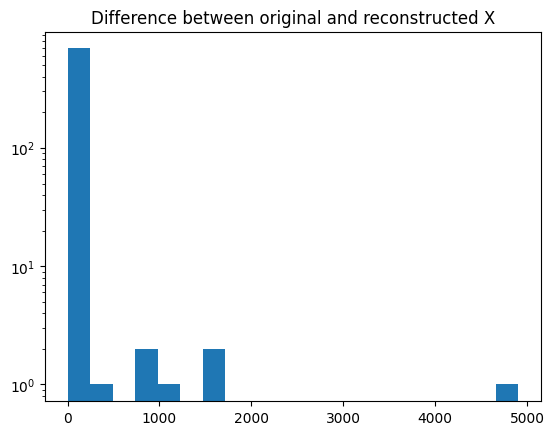

In [12]:
differences = [diff for _, _, diff in stats]
plt.hist(differences, bins=20)
plt.title("Difference between original and reconstructed X")
plt.yscale("log")
plt.show()

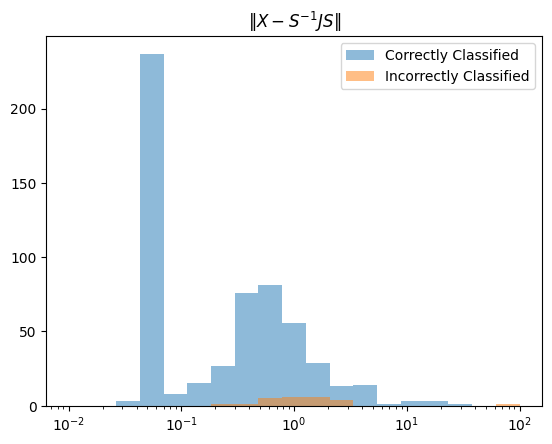

In [13]:
differences_true = [diff for true_type, pred_type, diff in stats if true_type == pred_type]
plt.hist(differences_true, bins=np.logspace(-2, 2, 20), alpha=.5, label='Correctly Classified')
differences_false = [diff for true_type, pred_type, diff in stats if true_type != pred_type]
plt.hist(differences_false, bins=np.logspace(-2, 2, 20), alpha=.5, label='Incorrectly Classified')
plt.xscale("log")
plt.title(r"$\| X - S^{-1} J S \|$")
plt.legend()
plt.show()

In [15]:
import csv 

with open("sandbox/stats_5_grad.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    
    # Optional: write a header
    writer.writerow(["true", "pred", "diff"])
    
    # Write the tuples
    writer.writerows(stats)

In [29]:
import csv

stats = []

with open("sandbox/stats_5_grad.csv", mode="r", newline="") as file:
    reader = csv.reader(file)
    
    # Skip header (remove this line if you didn't write a header)
    next(reader)
    
    for row in reader:
        a = int(row[0])
        b = int(row[1])
        c = float(row[2])
        stats.append((a, b, c))